## Imports

In [1]:
!pip install pymoo


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# IMPORTS
import numpy as np
import pandas as pd
import keras
from keras import layers
import random
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.termination.default import DefaultMultiObjectiveTermination
from pymoo.core.problem import Problem
from keras.utils import to_categorical

MAX_HARDWARE_VALUE = 6.0  # Maximum hardware value for devices
DOES_BATTERY_RUN_OUT = True  # Flag to indicate if battery can run out
UTILITY_DECREASE = 0.10   # Drop when device is selected and trains
UTILITY_INCREASE = 0.05   # Recovery when device is skipped in a round

ALPHA = 0.1

POPULATION_SIZE = 30 # should be 100
NUM_GENERATIONS = 5 # should be 10
NUM_ROUNDS = 10

EPOCHS = 2

DATA_SEED = 1
RUN_SEED = 1


import tensorflow as tf
import os

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds(RUN_SEED)

## Classes

In [3]:
# CLASSES

class Device:
    def __init__(self, id, ram, storage, cpu, bandwidth, battery, charging):
        self.id = id
        self.ram = ram
        self.storage = storage
        self.cpu = cpu
        self.bandwidth = bandwidth
        self.battery = battery
        self.charging = charging
        self.model: keras.Sequential = Server.create_model()
        self.last_round_participated = 0
        self.data = None  # Placeholder for dataset partition
        self.test_data = None
        self.number_of_times_fitted = 0
        self.hardware_value_sum = 0.0
        
        self.utility_score: float = 1.0  # Initialize utility score to 1.0
    
    @property
    def is_off(self):
        # Battery is deprecated; utility_score is the hard participation gate
        return self.utility_score < UTILITY_DECREASE
    
    def fit(self, x_train, y_train, epochs=1, verbose=0):
        # if DOES_BATTERY_RUN_OUT:
        #     if self.battery > 0.2:
        #         self.battery -= 0.1
        #         self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)
        #     else:
        #         self.battery = 0
        #         print("device turned off!")
        # else:
            self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)

    def lose_battery(self):
        if self.hardware_value_sum > 0.3:
            self.hardware_value_sum -= 0.3
        else:
            self.hardware_value_sum = 0
            print("device turned off!")

class Server:
    def __init__(self, devices_list: list[Device]):
        self.model: keras.Sequential = Server.create_model()
        self.current_learning_iteration = 0
        self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = []
        self.x_test_global = []
        self.y_test_global = []
        self.devices = devices_list
               
        # The variables below are used to keep track of the remaining rounds and generations and to store the variances
        # They do not logically belong to the Server class
        self.remaining_generation = 0
        self.remaining_round = 0
        self.variances = []  # List to store variances as [round, gen, solution, variance]
        self.pareto_fronts = [] # List to store pareto fronts as [round, gen, solution]

    def evaluate(self, x_test=None, y_test=None, verbose = 0):
        if x_test is None and y_test is None:
            test_loss, test_acc = self.model.evaluate(self.x_test_global, self.y_test_global, verbose)
            return test_loss, test_acc
        test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=verbose)
        return test_loss, test_acc

    def get_weights(self):
        return self.model.get_weights()

    def give_global_model_weights_to_bitstring_devices(self, bitstring, battery_depletion=True):
        if battery_depletion:
            for device in self.devices:
                if int(bitstring[int(device.id)]) == 1 and not device.is_off:
                    device.model.set_weights(self.model.get_weights())
        else:
            for device in self.devices:
                if int(bitstring[int(device.id)]) == 1:
                    device.model.set_weights(self.model.get_weights())
            

    def create_model() -> keras.Sequential:
        model = keras.Sequential([
            layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                        loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def aggregate_weights(self, bitstring):
        """Computes the weighted average of model weights from all devices and updates the global model."""
        def sum_all_nested_lists(list_of_lists):
            def recursive_sum(lists):
                if isinstance(lists[0], list):
                    return [recursive_sum([lst[i] for lst in lists]) for i in range(len(lists[0]))]
                else:
                    return sum(lists)

            return recursive_sum(list_of_lists)

        def multiply_nested_list(lst, factor):
            result = []
            for item in lst:
                if isinstance(item, list):
                    # Recursively handle sublists
                    result.append(multiply_nested_list(item, factor))
                else:
                    # Multiply number
                    result.append(item * factor)
            return result

        selected_devices: list[Device] = []
        for device in self.devices:
            if int(bitstring[int(device.id)]) == 1 and device.is_off == False:
                selected_devices.append(device)

        num_devices = len(selected_devices)
        if num_devices == 0:
            print("No devices available for aggregation.")
            return
        
        data_lengths = []

        for device in selected_devices:
            data_lengths.append(len(device.data[0]))

        sum_data = 0
        for data_len in data_lengths:
            sum_data += data_len

        data_fractions = []
        for device in selected_devices:
            data_fractions.append(len(device.data[0])/float(sum_data))

        normalized_weights = data_fractions

        aggregated_weights_devices = []
        for d in range(len(selected_devices)):
            aggregated_weights_devices.append(multiply_nested_list(self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(selected_devices[d].id)], normalized_weights[d]))

        aggregated_weights = sum_all_nested_lists(aggregated_weights_devices)

        return aggregated_weights


class NodeSelectionProblem(Problem):
    def __init__(self, devices: list[Device], server: Server, max_number_of_generations, max_number_of_rounds):
        super().__init__(
            n_var=len(devices),         # Number of variables (bitstring length)
            n_obj=3,                   # Number of objectives
            n_constr=0,                # No constraints
            xl=np.zeros(len(devices)),  # Lower bound (0)
            xu=np.ones(len(devices)),   # Upper bound (1)
            type_var=np.bool_          # Binary variables (bitstrings)
        )
        self.MAX_NUMBER_OF_GENERATIONS = max_number_of_generations
        self.MAX_NUMBER_OF_ROUNDS = max_number_of_rounds
        self.devices = devices
        self.server = server
        self.x_test_global = server.x_test_global
        self.y_test_global = server.y_test_global

        # Save the initial global model weights
        self.initial_global_weights = server.get_weights()

    def _evaluate(self, X, out, *args, **kwargs):
        MAX_NUMBER_OF_GENERATIONS = self.MAX_NUMBER_OF_GENERATIONS
        MAX_NUMBER_OF_ROUNDS = self.MAX_NUMBER_OF_ROUNDS
        """Evaluates objective values for each solution in the population."""
        num_solutions = len(X)
        F = np.zeros((num_solutions, 3))  # Initialize objective matrix

        for i, bitstring in enumerate(X):
            # print(f"evaluating: {bitstring}")
            # TODO: check bitstring type
            # Update device participation based on the bitstring
            selected_devices = [device for device, bit in zip(self.devices, bitstring) if int(bit) == 1]
            alive_selected = [d for d in selected_devices if not d.is_off and self.server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(d.id)] is not None]

            # Objective 1: Utility (maximize)
            if len(alive_selected) == 0:
                F[i, 0] = 1.0  # Worst possible score
            else:                
                avg_utility = np.mean([device.utility_score for device in alive_selected])
                F[i, 0] = 1.0 - avg_utility

            # Objective 2: Underperforming-client prioritization (minimize)
            if len(alive_selected) == 0:
                F[i, 1] = 1.0
            else:
                fairness_score = 0
                for device in alive_selected:
                    _, accuracy = self.server.evaluate(device.test_data[0], device.test_data[1], verbose=0)
                    fairness_score += accuracy
                F[i, 1] = fairness_score / len(alive_selected)

            # Objective 3: Global Model Accuracy (Performance) (maximize)
            if len(alive_selected) == 0:
                F[i, 2] = 1.0
            else:
                temp_global_model = Server.create_model()
                temp_global_model.set_weights(self.performance_objective_aggregation(alive_selected))
                _, global_accuracy = temp_global_model.evaluate(
                    self.server.x_test_global, self.server.y_test_global, verbose=0
                )
                F[i, 2] = 1 - global_accuracy

        # self.server.remaining_generation -= 1    moved to ParetoLogger.notify()
        out["F"] = F  # Set the objective values

    def performance_objective_aggregation(self, selected_devices: list[Device]):
        # Build a temporary bitstring from the selected devices
        bitstring = [0] * len(self.server.devices)
        for device in selected_devices:
            bitstring[int(device.id)] = 1
        return self.server.aggregate_weights(bitstring)
    



## Functions

In [4]:
# Functions

def fit_bitstring_devices(bitstring, server: Server, epochs=EPOCHS, skip_off=False):
    '''
    server: for using its "current_learning_iteration" variable
    '''

    server.current_learning_iteration += 1
    for device in server.devices:
        if skip_off:
            if int(bitstring[int(device.id)]) == 1:
                device.fit(device.data[0], device.data[1], epochs=epochs, verbose=0)
                # print(device.id)
                device.last_round_participated = server.current_learning_iteration
                server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(device.id)] = device.model.get_weights()
                device.number_of_times_fitted += 1            
        
        else:
            if int(bitstring[int(device.id)]) == 1 and not device.is_off:            
                device.fit(device.data[0], device.data[1], epochs=epochs, verbose=0)
                # print(device.id)
                device.last_round_participated = server.current_learning_iteration
                server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(device.id)] = device.model.get_weights()
                device.number_of_times_fitted += 1
                device.utility_score = max(0.0, round(device.utility_score - UTILITY_DECREASE, 2))


def niid_labeldir_split(x_data, y_data, num_clients, beta, seed=DATA_SEED):
    num_classes = 10
    y_indices = np.array([np.argmax(label) for label in y_data])  # From one-hot to class index
    
    rng = np.random.default_rng(seed)  # Local random generator

    # Prepare client partitions
    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(y_indices == k)[0]
        rng.shuffle(idx_k)

        # Dirichlet distribution for class k
        proportions = rng.dirichlet(np.repeat(beta, num_clients))

        # Scale proportions to match the number of available samples
        proportions = np.array([int(p * len(idx_k)) for p in proportions])
        # Fix total due to rounding
        while sum(proportions) < len(idx_k):
            proportions[np.argmin(proportions)] += 1
        while sum(proportions) > len(idx_k):
            proportions[np.argmax(proportions)] -= 1

        start = 0
        for i in range(num_clients):
            size = proportions[i]
            client_indices[i].extend(idx_k[start:start + size])
            start += size

    return client_indices


def random_hardware_value_for_devices(devices: list[Device]):
    random_values = [3.91, 0.62, 1.79, 4.96, 5.87, 2.14, 1.41, 5.18, 2.80, 3.00, 0.20, 1.02, 5.73, 0.69, 4.27,
                     5.37, 1.62, 0.93, 3.61, 2.90, 4.53, 2.13, 3.01, 0.07, 1.34, 3.90, 0.28, 1.89, 5.95, 2.76]
    
    for idx in range(len(devices)):
        devices[idx].hardware_value_sum = random_values[idx]
    
    print("Successfully gave each device a random value between 0 and 6 for its hardware objective!")


## Load Data

### Load Devices

In [5]:
# Load dataset from CSV
csv_file = 'devices.csv'
df = pd.read_csv(csv_file)
df.columns = df.columns.str.strip().str.lower()

# Convert CSV rows into device objects
devices = []

for _, row in df.iterrows():
    device = Device(
        row['id'], row['ram'], row['storage'], row['cpu'], row['bandwidth'], row['battery'],
        row.get('charging', 0)
    )
    device.utility_score = row['battery']
    devices.append(device)


# LIMIT TO 30 DEVICES
devices = devices[:30]

random_hardware_value_for_devices(devices)

d:\Github Repos\FL\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Successfully gave each device a random value between 0 and 6 for its hardware objective!


### Object Initializations

In [6]:
for device in devices:
    print(device.id)
    print(device.hardware_value_sum)
    print(device.battery)
    print(device.battery+device.ram+device.storage+device.cpu+device.bandwidth+device.charging)

0.0
3.91
0.1031238688359326
2.4928382735072256
1.0
0.62
0.9025529066795668
3.2849102894927706
2.0
1.79
0.5052523724478571
2.479004755181064
3.0
4.96
0.8264574661077416
3.6053494049560646
4.0
5.87
0.3200496010306117
2.8765445580063145
5.0
2.14
0.8955232284962005
2.546825521004018
6.0
1.41
0.3892016787341631
2.7668162624681143
7.0
5.18
0.0108376514802983
2.758204625210855
8.0
2.8
0.9053819764192635
3.7725268366840417
9.0
3.0
0.0912866767861335
2.5863101880601036
10.0
0.2
0.3193136375904148
1.8875506791440282
11.0
1.02
0.9500619670508048
3.061396413656667
12.0
5.73
0.950607146937556
4.546114213392503
13.0
0.69
0.5734378881232861
2.9600773810663465
14.0
4.27
0.6318372121697993
3.158886471189339
15.0
5.37
0.4484455219783197
3.6377250762468045
16.0
1.62
0.2932107716980645
3.3512510378870353
17.0
0.93
0.3286645453699159
2.1966655395063452
18.0
3.61
0.6725184560770384
3.990035019042393
19.0
2.9
0.75237452943768
2.8894084511328995
20.0
4.53
0.7915790437258485
3.555098389929464
21.0
2.13
0.78961

In [7]:
# Global Model
server = Server(devices_list=devices)
server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = [None for _ in range(len(devices))]

### Split Data Among Devices

In [8]:


# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Convert labels to categorical (one-hot encoded)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Normalize data and reshape for CNN
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # Add channel dimension

x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1)  # Add channel dimension


# Lower the amount of data for devices
x_train = x_train[:int(len(x_train)/8)] # was 8
y_train = y_train[:int(len(y_train)/8)]


# Correct test split
split_index = int(0.8 * len(x_test))
x_test_devices, y_test_devices = x_test[:split_index], y_test[:split_index]
server.x_test_global, server.y_test_global = x_test[split_index:], y_test[split_index:]

# Training data (for devices)
x_train_devices, y_train_devices = x_train, y_train

# Split training data among devices
alpha = ALPHA  # lower = more skewed
num_devices = len(devices)
split_indices = niid_labeldir_split(x_train_devices, y_train_devices, num_devices, alpha, seed=DATA_SEED)

for i, device in enumerate(devices):
    idxs = split_indices[i]

    from sklearn.model_selection import train_test_split

    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(x_train_devices[idxs], y_train_devices[idxs], test_size=0.3, random_state=42)

    device.data = [X_train, y_train]
    device.test_data = [X_test, y_test]

    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)


#TODO:
# how does each objective get better through populations? maybe put em on a scale

X_train shape: (224, 28, 28, 1)
X_test shape: (97, 28, 28, 1)
y_train shape: (224, 10)
y_test shape: (97, 10)
X_train shape: (177, 28, 28, 1)
X_test shape: (76, 28, 28, 1)
y_train shape: (177, 10)
y_test shape: (76, 10)
X_train shape: (9, 28, 28, 1)
X_test shape: (5, 28, 28, 1)
y_train shape: (9, 10)
y_test shape: (5, 10)
X_train shape: (16, 28, 28, 1)
X_test shape: (7, 28, 28, 1)
y_train shape: (16, 10)
y_test shape: (7, 10)
X_train shape: (352, 28, 28, 1)
X_test shape: (151, 28, 28, 1)
y_train shape: (352, 10)
y_test shape: (151, 10)
X_train shape: (197, 28, 28, 1)
X_test shape: (85, 28, 28, 1)
y_train shape: (197, 10)
y_test shape: (85, 10)
X_train shape: (252, 28, 28, 1)
X_test shape: (108, 28, 28, 1)
y_train shape: (252, 10)
y_test shape: (108, 10)
X_train shape: (253, 28, 28, 1)
X_test shape: (109, 28, 28, 1)
y_train shape: (253, 10)
y_test shape: (109, 10)
X_train shape: (486, 28, 28, 1)
X_test shape: (209, 28, 28, 1)
y_train shape: (486, 10)
y_test shape: (209, 10)
X_train shap

### NonIID-ness visualization

In [9]:
print(devices[0].data[1])
onehot = devices[0].data[1]          # Your one-hot array
int_labels = np.argmax(onehot, axis=1)  # Convert
print(int_labels)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[5 5 5 5 5 5 5 5 5 5 5 5 2 5 5 2 5 5 5 5 5 5 5 2 5 2 5 5 5 5 5 2 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 5 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 7 5 5 0 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 7 5 5 3 5 2 5 5 5 5 5 5 5 5 5 5 5 5 6 2
 5 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 5 7 5 5 5 5 5 5 5 5 1 5 5 5 5 5 5 5 5 5
 2 5 5 5 7 5 5 5 5 5 5 5 8 5 5 5 5 5 5 2 5 5 5 5 5 5 5 5 5 5 5 5 9 2 5 5 5
 5 5]


NON-IID ANALYSIS SUMMARY
Number of devices: 30
Total samples: 5238

--- Heterogeneity Metrics ---
Mean EMD: 2.0581 ± 0.6735
Mean KL Divergence: 1.3841 ± 0.4162
Max EMD (worst device): 3.5978
Estimated Dirichlet α: 2.2872 (lower = more heterogeneous)

Most skewed device: Device 8
  Top 3 digits: [0 1 3]
  Concentration: 46.9% in one class

Non-IID Severity: Severe


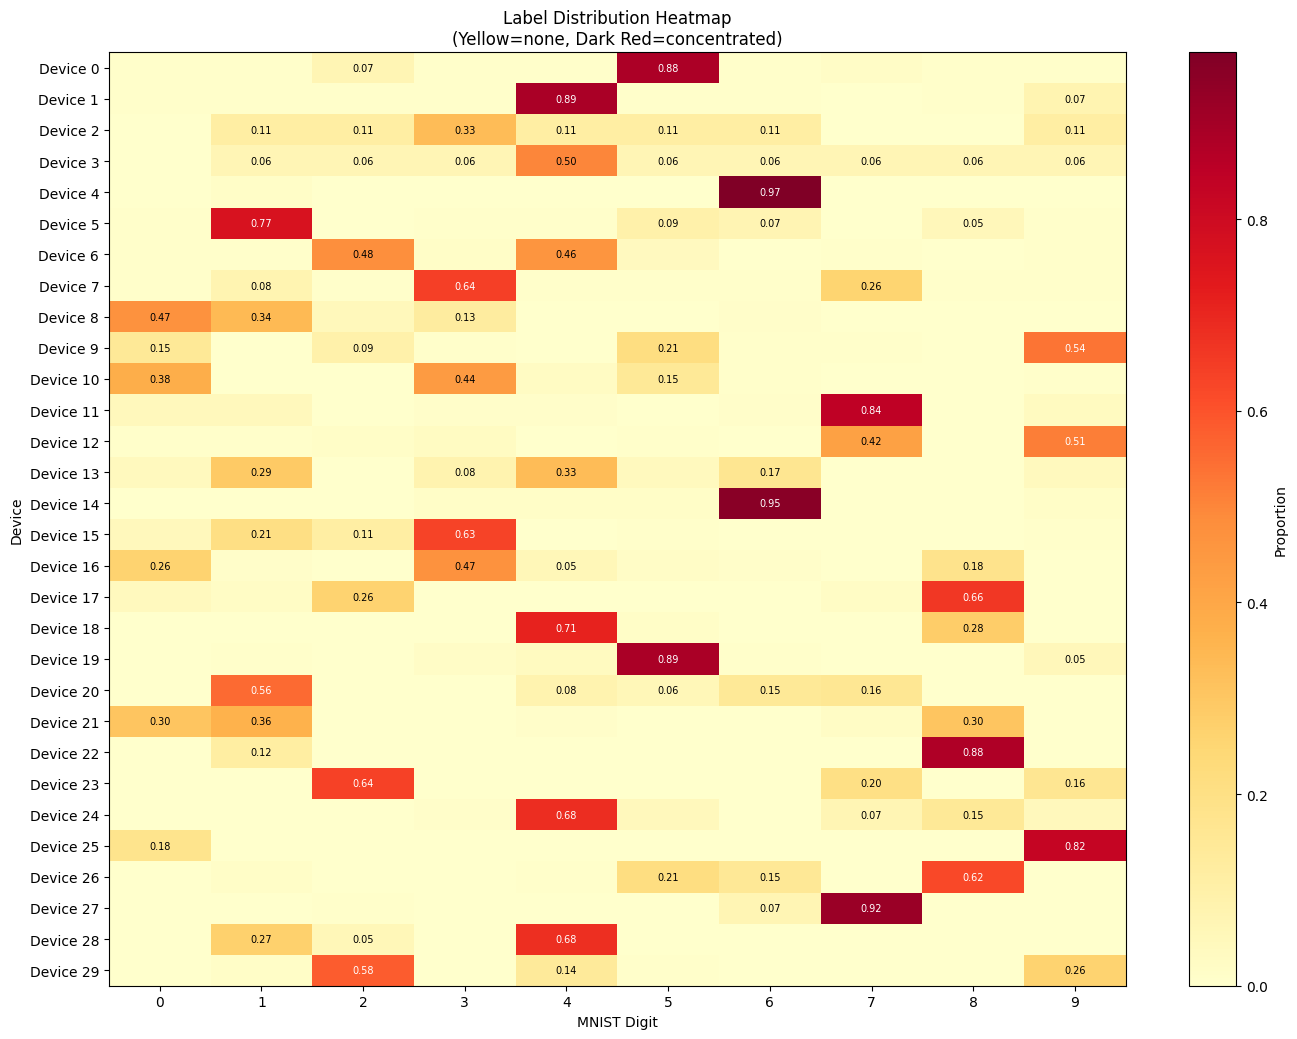

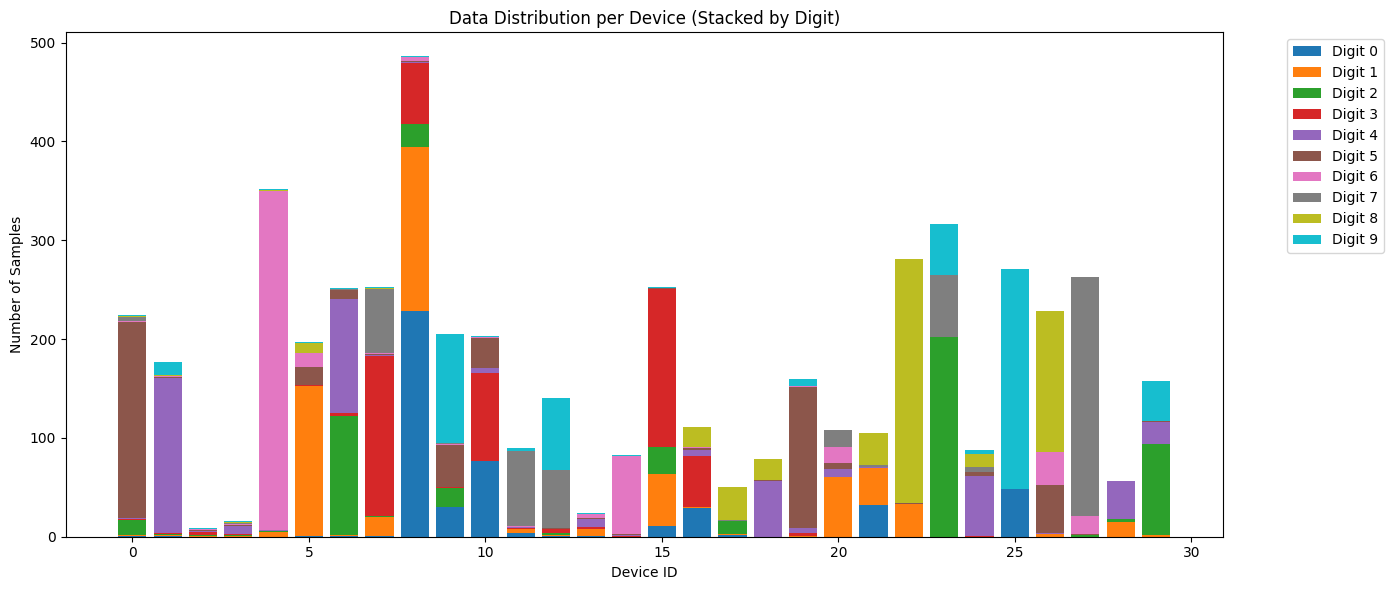

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import wasserstein_distance
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ============================================================
# CORE: Build distribution from your devices
# ============================================================

def build_distribution(devices, data_attr='data', label_index=1):
    """
    Build label distribution from devices with one-hot encoded labels.
    Returns: (distribution, raw_counts) tuple
    """
    num_devices = len(devices)
    num_classes = 10
    raw_counts = np.zeros((num_devices, num_classes), dtype=int)
    
    for i, device in enumerate(devices):
        onehot_labels = getattr(device, data_attr)[label_index]
        int_labels = np.argmax(onehot_labels, axis=1)
        for label in range(num_classes):
            raw_counts[i, label] = np.sum(int_labels == label)
    
    row_sums = raw_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    distribution = raw_counts / row_sums
    
    return distribution, raw_counts


# ============================================================
# METRICS
# ============================================================

def calculate_euclidean_per_device(devices=None, distribution=None):
    """Euclidean distance from uniform distribution per device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    # Vectorized: sqrt(sum((P - Q)^2)) for all devices at once
    return np.sqrt(np.sum((dist - global_dist) ** 2, axis=1))


def calculate_emd_per_device(devices=None, distribution=None):
    """Earth Mover's Distance from uniform distribution per device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    emd_scores = []
    for i in range(len(dist)):
        device_samples = np.repeat(np.arange(num_classes), (dist[i] * 10000).astype(int))
        global_samples = np.repeat(np.arange(num_classes), (global_dist * 10000).astype(int))
        emd = wasserstein_distance(device_samples, global_samples)
        emd_scores.append(emd)
    
    return np.array(emd_scores)


def calculate_kl_divergence(devices=None, distribution=None, epsilon=1e-10):
    """KL(P_device || P_global) for each device"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    num_classes = dist.shape[1]
    global_dist = np.ones(num_classes) / num_classes
    
    kl_scores = []
    for i in range(len(dist)):
        p = dist[i] + epsilon
        q = global_dist
        kl = np.sum(p * np.log(p / q))
        kl_scores.append(kl)
    
    return np.array(kl_scores)


def estimate_dirichlet_alpha(devices=None, distribution=None):
    """Rough estimate of Dirichlet concentration parameter. Lower = more heterogeneous."""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    variances = np.var(dist, axis=0)
    mean_var = np.mean(variances)
    estimated_alpha = 0.1 / (mean_var + 0.001)
    return estimated_alpha


# ============================================================
# VISUALIZATIONS
# ============================================================

def plot_heatmap(devices=None, distribution=None):
    """Label distribution heatmap across devices"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(dist) * 0.35)))
    
    im = ax.imshow(dist, aspect='auto', cmap='YlOrRd', vmin=0, vmax=dist.max())
    
    ax.set_xticks(range(10))
    ax.set_xticklabels([f'{i}' for i in range(10)])
    ax.set_yticks(range(len(dist)))
    ax.set_yticklabels([f'Device {i}' for i in range(len(dist))])
    
    ax.set_xlabel('MNIST Digit')
    ax.set_ylabel('Device')
    ax.set_title('Label Distribution Heatmap\n(Yellow=none, Dark Red=concentrated)')
    
    for i in range(len(dist)):
        for j in range(10):
            if dist[i, j] >= 0.05:
                color = "white" if dist[i, j] > 0.5 else "black"
                ax.text(j, i, f'{dist[i, j]:.2f}',
                       ha="center", va="center", color=color, fontsize=7)
    
    plt.colorbar(im, ax=ax, label='Proportion')
    plt.tight_layout()
    plt.show()
    
    return dist


def plot_stacked_bars(devices):
    """Stacked bar chart showing absolute data volume per device with class breakdown"""
    dist, counts = build_distribution(devices)
    num_devices = len(devices)
    num_classes = 10
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bottom = np.zeros(num_devices)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    
    for digit in range(num_classes):
        ax.bar(range(num_devices), counts[:, digit], 
               bottom=bottom, label=f'Digit {digit}', color=colors[digit])
        bottom += counts[:, digit]
    
    ax.set_xlabel('Device ID')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Data Distribution per Device (Stacked by Digit)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_divergence_summary(devices=None, distribution=None):
    """Box plots of EMD and KL divergence across devices"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    emd = calculate_emd_per_device(distribution=dist)
    kl = calculate_kl_divergence(distribution=dist)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].boxplot(emd, vert=True)
    axes[0].set_title(f'EMD from Uniform Distribution\n(Mean: {emd.mean():.3f})')
    axes[0].set_ylabel('Wasserstein Distance')
    
    axes[1].boxplot(kl, vert=True)
    axes[1].set_title(f'KL Divergence from Uniform\n(Mean: {kl.mean():.3f})')
    axes[1].set_ylabel('KL Divergence')
    
    plt.suptitle('Non-IID Severity Summary', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_device_similarity(devices=None, distribution=None):
    """PCA plot clustering devices by label distribution similarity"""
    if distribution is not None:
        dist = distribution
    else:
        dist, _ = build_distribution(devices)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(dist)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = ax.scatter(coords[:, 0], coords[:, 1], 
                        c=range(len(dist)), 
                        cmap='tab20', s=200, edgecolors='black')
    
    for i, (x, y) in enumerate(coords):
        ax.annotate(f'D{i}', (x, y), fontsize=10, ha='center', va='center')
    
    ax.set_title('Device Similarity by Label Distribution (PCA)\n'
                 'Closer devices = more similar data distributions')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.colorbar(scatter, label='Device ID')
    plt.tight_layout()
    plt.show()


# ============================================================
# COMPLETE ANALYSIS (runs everything)
# ============================================================

def full_noniid_analysis(devices):
    """Run complete non-IID analysis with all metrics and plots"""
    dist, counts = build_distribution(devices)
    
    # Metrics
    emd = calculate_emd_per_device(distribution=dist)
    kl = calculate_kl_divergence(distribution=dist)
    alpha = estimate_dirichlet_alpha(distribution=dist)
    
    # Summary
    print("=" * 55)
    print("NON-IID ANALYSIS SUMMARY")
    print("=" * 55)
    print(f"Number of devices: {len(devices)}")
    print(f"Total samples: {counts.sum()}")
    print(f"\n--- Heterogeneity Metrics ---")
    # TODO: ADD EUCLIDEAN DISTANCE HERE
    print(f"Mean EMD: {emd.mean():.4f} ± {emd.std():.4f}")
    print(f"Mean KL Divergence: {kl.mean():.4f} ± {kl.std():.4f}")
    print(f"Max EMD (worst device): {emd.max():.4f}")
    print(f"Estimated Dirichlet α: {alpha:.4f} (lower = more heterogeneous)")
    
    # Most skewed device
    worst_idx = np.argmax(emd)
    print(f"\nMost skewed device: Device {worst_idx}")
    top3 = np.argsort(dist[worst_idx])[-3:][::-1]
    print(f"  Top 3 digits: {top3}")
    print(f"  Concentration: {dist[worst_idx].max():.1%} in one class")
    
    # Severity classification
    mean_emd = emd.mean()
    if mean_emd < 0.5:
        severity = "Mild"
    elif mean_emd < 1.5:
        severity = "Moderate"
    else:
        severity = "Severe"
    print(f"\nNon-IID Severity: {severity}")
    print("=" * 55)
    
    # Generate all plots
    plot_heatmap(distribution=dist)
    plot_stacked_bars(devices)
    # plot_divergence_summary(distribution=dist)
    # plot_device_similarity(distribution=dist)
    
    return {
        'distribution': dist,
        'raw_counts': counts,
        'emd': emd,
        'kl': kl,
        'dirichlet_alpha': alpha,
        'severity': severity
    }


# ============================================================
# USAGE
# ============================================================

# Run everything:
results = full_noniid_analysis(devices)

# Or run individual functions:
# dist, counts = build_distribution(devices)
# plot_heatmap(distribution=dist)
# emd = calculate_emd_per_device(distribution=dist)

In [11]:
# test
a, b =devices[15].test_data
print(len(a))

109


### Load Other Data

In [12]:
class FLLogger:
    def __init__(self):
        self.logs = {}
    
    def log_round(self, round_num: int, round_log: dict):
        self.logs[str(round_num)] = round_log
    
    def save_log(self, filename: str):
        with open(filename, 'w') as f:
            json.dump(self.logs, f)



## First Iteration

In [13]:
# First Iteration
bitstring = [1 for _ in range(len(devices))]
print(bitstring)



#####################
fl_logger = FLLogger()
round_logs = {}
round_logs["bitstring"] = bitstring
round_logs["selected_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1]
round_logs["num_selected_clients"] = sum(bitstring)
round_logs["participating_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]
round_logs["num_participating_clients"] = len(round_logs["participating_clients"])
round_logs["average_utility_selected_clients_before_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
round_logs["average_utility_participating_clients_before_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
round_logs["per_client_utility_before_fit"] = {device.id: device.utility_score for device in server.devices}
accuracies = []
for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    loss, accuracy = server.evaluate(x_test, y_test)
    accuracies.append(accuracy)
round_logs["per_client_accuracy_before_fit"] = {device.id: acc for device, acc in zip(server.devices, accuracies)}
accuracies = None
#####################



# Save weights to a file
# The file name should end in .weights.h5
# The weights can be loaded into a model using model.load_weights('model.weights.h5')
server.model.load_weights('my_model.weights.h5')

# global model sends its weights to all devices
server.give_global_model_weights_to_bitstring_devices(bitstring, battery_depletion=False)
server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = [server.model.get_weights() for _ in range(len(devices))]


test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")
print("------------------------------------------------------------")
fit_bitstring_devices(bitstring, server, skip_off=True)
# NEW: Changed to  the code below, so all devices participate first time, even if is_off is true
for device in devices:
    device:Device
    # device.fit(device.data[0], device.data[1], epochs=EPOCHS, verbose=0)
server.model.set_weights(server.aggregate_weights(bitstring))

print("------------------------------------------------------------")
test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")



accuracies = []

for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    
    loss, accuracy = server.evaluate(x_test, y_test)
    
    accuracies.append(accuracy)
    print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

VARIANCE = np.var(accuracies)
VARIANCE_SCORE = 1.0/VARIANCE
MEAN = np.mean(accuracies)
STANDARD_DEVIATION = np.std(accuracies)
FAIRNESS = 1.0/STANDARD_DEVIATION

###################################################
round_logs["average_utility_selected_clients_after_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
round_logs["average_utility_participating_clients_after_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
round_logs["per_client_utility_after_fit"] = {device.id: device.utility_score for device in server.devices}
round_logs["global_test_accuracy"] = test_acc
round_logs["mean_client_accuracy"] = MEAN
round_logs["fairness"] = FAIRNESS
round_logs["worst_client_accuracy"] = min(accuracies)
###################################################


fl_logger.log_round("warm_up", round_logs)
round_logs = None

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0948 - loss: 2.3097
Global Model Accuracy: 0.10
------------------------------------------------------------
------------------------------------------------------------
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1890 - loss: 2.2081
Global Model Accuracy: 0.20
Device 0.0 Accuracy: 0.0
Device 1.0 Accuracy: 0.0
Device 2.0 Accuracy: 0.2
Device 3.0 Accuracy: 0.14
Device 4.0 Accuracy: 0.93
Device 5.0 Accuracy: 0.73
Device 6.0 Accuracy: 0.02
Device 7.0 Accuracy: 0.09
Device 8.0 Accuracy: 0.25
Device 9.0 Accuracy: 0.02
Device 10.0 Accuracy: 0.05
Device 11.0 Accuracy: 0.08
Device 12.0 Accuracy: 0.03
Device 13.0 Accuracy: 0.27
Device 14.0 Accuracy: 1.0
Device 15.0 Accuracy: 0.21
Device 16.0 Accuracy: 0.06
Device 17.0 Accuracy: 0.0
Device 18.0 Accuracy: 0.06
Device 19.0 Accuracy: 0.0
Device 20.0 Accuracy: 0.66
Device 21.0 Accuracy: 0.27
Device 

## NSGA2 Loop

In [14]:
# Parameters
print(f"Population Size: {POPULATION_SIZE}")
print(f"Number of Generations: {NUM_GENERATIONS}")
print(f"Number of Rounds: {NUM_ROUNDS}")

server.remaining_generation = NUM_GENERATIONS
server.remaining_round = NUM_ROUNDS

Population Size: 30
Number of Generations: 5
Number of Rounds: 10


In [15]:
# Object Initializations

problem = NodeSelectionProblem(
    devices=devices,
    server=server,
    max_number_of_generations=NUM_GENERATIONS,
    max_number_of_rounds=NUM_ROUNDS
)


# Step 2: Configure NSGA-II Algorithm
algorithm = NSGA2(
    pop_size=POPULATION_SIZE,
    sampling=BinaryRandomSampling(),      # Random bitstrings
    crossover=TwoPointCrossover(),        # Two-point crossover
    mutation=BitflipMutation(),           # Bit flip mutation
    eliminate_duplicates=True             # Avoid duplicate solutions
)


In [16]:
# DEBUG:
print(server.x_test_global.shape)
print(server.y_test_global.shape)

print(x_train.shape)
print(y_train.shape)

(2000, 28, 28, 1)
(2000, 10)
(7500, 28, 28, 1)
(158, 10)


In [17]:

#############################################
#############################################
# Global test accuracy
# Mean client accuracy
# Fairness
# Worst-client accuracy
# Number of selected clients
# Number of actually participating/eligible clients
# Average utility of selected clients
# Average utility of actually participating clients
# Per-client accuracy
# Per-client utility/battery
# Which clients were selected
# Which clients actually participated

# saved_logs[str(i+1)] = {
#     "global_test_accuracy": test_acc,
#     "mean_client_accuracy": MEAN,
#     "fairness": FAIRNESS,
#     "worst_client_accuracy": min(accuracies),
    # "num_selected_clients": sum(bitstring),
    # "num_participating_clients": len([device for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]),
    # "average_utility_selected_clients": np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1]),
    # "average_utility_participating_clients": np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]),
    # "per_client_accuracy": {device.id: acc for device, acc in zip(server.devices, accuracies)},
    # "per_client_utility": {device.id: device.utility_score for device in server.devices},
    # "selected_clients": [device.id for device, bit in zip(server.devices, bitstring) if bit == 1],
    # "participating_clients": [device.id for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]
# }
#############################################
#############################################
# And at the end of the 10 rounds:

# Final global accuracy
# Final mean client accuracy
# Final fairness
# Final worst-client accuracy
# Total/average number of selected clients per round
# Total/average number of participating clients per round
# Participation count for each client


In [18]:
import os
import json
import numpy as np
import pandas as pd

from pymoo.core.callback import Callback


class ParetoLogger(Callback):
    """
    Comprehensive logging callback for NSGA-II client-selection experiments.

    Drop-in replacement for the existing ParetoLogger.

    Existing attributes preserved for compatibility:
        self.data["pareto_fronts"]
        self.data["pareto_solutions"]
        self.variances
        self.server.variances

    Additional functionality:
        - Logs every Pareto solution at every NSGA-II generation.
        - Preserves the exact NSGA-II bitstring.
        - Records selected vs. available/unavailable clients separately.
        - Records objective values.
        - Records client accuracies.
        - Records utility statistics.
        - Records selection statistics.
        - Records generation and FL round.
        - Saves results to separate CSV files.

    Important:
        The logger NEVER changes the NSGA-II bitstring.

        If NSGA-II produces:
            [1, 0, 1, 1, 0, ...]

        that exact solution is stored as the selected chromosome.

        Availability is recorded separately so that:
            selected clients
        and
            actually available selected clients
        remain distinguishable.
    """

    def __init__(
        self,
        server: "Server",
        devices: list,
        max_rounds,
        max_generations
    ):
        super().__init__()

        # ============================================================
        # Existing attributes -- preserved for compatibility
        # ============================================================

        self.data["pareto_fronts"] = []
        self.data["pareto_solutions"] = []

        self.server = server
        self.devices = devices

        self.max_rounds = max_rounds
        self.max_generations = max_generations

        # Existing format:
        # [round, generation, bitstring, variance]
        self.variances = []

        # ============================================================
        # New structured logging containers
        # ============================================================

        # One record for every Pareto solution at every generation.
        self.pareto_records = []

        # One record for the selected Pareto solution per FL round.
        # This is populated later using log_selected_solution().
        self.selected_solution_records = []

        # One record for every client in every logged Pareto solution.
        # Useful for detailed client-level analysis.
        self.client_records = []

        # One record per NSGA-II generation.
        self.generation_records = []

        # One record per FL round.
        # This can later be supplemented by the main experiment loop.
        self.round_records = []

        # ============================================================
        # Internal state
        # ============================================================

        self.current_round = None
        self.current_generation = None

    # =================================================================
    # Helper methods
    # =================================================================

    def _get_round_index(self):
        """
        Determine the current FL round from server.remaining_round.

        Your existing experiment updates remaining_round before
        running NSGA-II, so this preserves the same round calculation
        used by the previous logger.
        """

        try:
            return self.max_rounds - self.server.remaining_round
        except Exception:
            return None

    def _safe_device_id(self, device):
        """Return device ID as an integer where possible."""

        try:
            return int(device.id)
        except Exception:
            return device.id

    def _get_selected_devices(self, bitstring):
        """
        Return devices selected by the exact NSGA-II chromosome.

        IMPORTANT:
        This function does NOT check whether the device is off.

        Therefore this represents the exact chromosome produced by
        NSGA-II.
        """

        return [
            device
            for device, bit in zip(self.devices, bitstring)
            if int(bit) == 1
        ]

    def _get_available_selected_devices(self, selected_devices):
        """
        Return the subset of selected devices that are currently
        available.

        This DOES NOT modify the original selected_devices list.
        """

        return [
            device
            for device in selected_devices
            if not device.is_off
        ]

    def _get_unavailable_selected_devices(self, selected_devices):
        """Return selected devices that are currently off."""

        return [
            device
            for device in selected_devices
            if device.is_off
        ]

    def _evaluate_device_accuracies(self, devices):
        """
        Evaluate the current global model on each supplied client's
        local test set.

        Returns:
            dictionary:
                {
                    client_id: accuracy
                }
        """

        accuracies = {}

        for device in devices:

            try:
                _, accuracy = self.server.evaluate(
                    device.test_data[0],
                    device.test_data[1],
                    verbose=0
                )

                accuracies[self._safe_device_id(device)] = float(accuracy)

            except Exception as e:

                print(
                    f"Warning: could not evaluate client "
                    f"{self._safe_device_id(device)}: {e}"
                )

                accuracies[self._safe_device_id(device)] = np.nan

        return accuracies

    def _get_utility_values(self, devices):
        """Return utility values for the supplied devices."""

        values = []

        for device in devices:

            try:
                values.append(float(device.utility_score))
            except Exception:
                pass

        return values

    def _calculate_statistics(self, values):
        """
        Calculate mean, variance and standard deviation.

        NaN values are ignored.
        """

        values = np.asarray(values, dtype=float)

        values = values[~np.isnan(values)]

        if len(values) == 0:
            return {
                "mean": np.nan,
                "variance": np.nan,
                "std": np.nan
            }

        if len(values) == 1:
            return {
                "mean": float(values[0]),
                "variance": 0.0,
                "std": 0.0
            }

        return {
            "mean": float(np.mean(values)),
            "variance": float(np.var(values)),
            "std": float(np.std(values))
        }

    # =================================================================
    # Main pymoo callback
    # =================================================================

    def notify(self, algorithm):

        # ------------------------------------------------------------
        # Generation information
        # ------------------------------------------------------------

        generation = int(algorithm.n_gen)

        self.current_generation = generation

        round_idx = self._get_round_index()

        self.current_round = round_idx

        # Preserve existing server bookkeeping.
        self.server.remaining_generation -= 1

        # ------------------------------------------------------------
        # Get current Pareto-optimal population
        # ------------------------------------------------------------

        opt = algorithm.opt

        if opt is None:
            return

        F = opt.get("F")
        X = opt.get("X")

        if F is None or X is None:
            return

        F = np.asarray(F)
        X = np.asarray(X)

        print(
            f"Generation {generation}: "
            f"{len(X)} solutions in opt"
        )

        # ------------------------------------------------------------
        # Preserve existing data structure
        # ------------------------------------------------------------

        self.data["pareto_fronts"].append(F.copy())
        self.data["pareto_solutions"].append(X.copy())

        # ------------------------------------------------------------
        # Generation-level record
        # ------------------------------------------------------------

        self.generation_records.append({
            "round": round_idx,
            "generation": generation,
            "num_pareto_solutions": len(X)
        })

        # ------------------------------------------------------------
        # Process every Pareto solution
        # ------------------------------------------------------------

        for solution_index, (objective_values, bitstring) in enumerate(
            zip(F, X)
        ):

            # Convert Boolean / numpy values to clean integers.
            bitstring = np.asarray(bitstring).astype(int)

            # Exact chromosome as produced by NSGA-II.
            bitstring_str = "".join(
                map(str, bitstring.tolist())
            )

            # --------------------------------------------------------
            # EXACT selected set
            # --------------------------------------------------------

            selected_devices = self._get_selected_devices(bitstring)

            # --------------------------------------------------------
            # Availability is recorded separately.
            #
            # IMPORTANT:
            # selected_devices remains untouched.
            # --------------------------------------------------------

            available_selected_devices = (
                self._get_available_selected_devices(
                    selected_devices
                )
            )

            unavailable_selected_devices = (
                self._get_unavailable_selected_devices(
                    selected_devices
                )
            )

            selected_ids = [
                self._safe_device_id(device)
                for device in selected_devices
            ]

            available_ids = [
                self._safe_device_id(device)
                for device in available_selected_devices
            ]

            unavailable_ids = [
                self._safe_device_id(device)
                for device in unavailable_selected_devices
            ]

            # --------------------------------------------------------
            # Client accuracy
            #
            # We intentionally calculate this on the EXACT selected
            # set, not only the available subset.
            #
            # This preserves information about the chromosome itself.
            # --------------------------------------------------------

            accuracy_dict = self._evaluate_device_accuracies(
                selected_devices
            )

            accuracy_values = [
                value
                for value in accuracy_dict.values()
                if not np.isnan(value)
            ]

            accuracy_stats = self._calculate_statistics(
                accuracy_values
            )

            # --------------------------------------------------------
            # Utility statistics
            #
            # Again, record both selected and available-selected
            # populations separately.
            # --------------------------------------------------------

            selected_utilities = self._get_utility_values(
                selected_devices
            )

            available_utilities = self._get_utility_values(
                available_selected_devices
            )

            selected_utility_stats = self._calculate_statistics(
                selected_utilities
            )

            available_utility_stats = self._calculate_statistics(
                available_utilities
            )

            # --------------------------------------------------------
            # Objective values
            # --------------------------------------------------------

            obj1 = (
                float(objective_values[0])
                if len(objective_values) > 0
                else np.nan
            )

            obj2 = (
                float(objective_values[1])
                if len(objective_values) > 1
                else np.nan
            )

            obj3 = (
                float(objective_values[2])
                if len(objective_values) > 2
                else np.nan
            )

            # --------------------------------------------------------
            # Fairness
            #
            # This is an analysis metric, NOT a replacement for the
            # objective value supplied by NSGA-II.
            #
            # We preserve both.
            # --------------------------------------------------------

            variance = accuracy_stats["variance"]
            std = accuracy_stats["std"]

            if np.isnan(variance):
                fairness_inverse_variance = np.nan

            elif variance == 0:
                fairness_inverse_variance = np.inf

            else:
                fairness_inverse_variance = 1.0 / variance

            # Preserve your old variance record format.
            self.variances.append([
                round_idx,
                generation,
                bitstring_str,
                (
                    round(fairness_inverse_variance, 2)
                    if np.isfinite(fairness_inverse_variance)
                    else fairness_inverse_variance
                )
            ])

            # --------------------------------------------------------
            # Main Pareto record
            # --------------------------------------------------------

            pareto_record = {

                # Experiment position
                "round": round_idx,
                "generation": generation,
                "solution_index": solution_index,

                # Exact NSGA-II chromosome
                "bitstring": bitstring_str,

                # Objective values
                "objective_1": obj1,
                "objective_2": obj2,
                "objective_3": obj3,

                # Selected-set information
                "num_selected": len(selected_devices),
                "selected_client_ids": json.dumps(selected_ids),

                # Availability information
                "num_available_selected": (
                    len(available_selected_devices)
                ),
                "available_selected_client_ids": (
                    json.dumps(available_ids)
                ),

                "num_unavailable_selected": (
                    len(unavailable_selected_devices)
                ),
                "unavailable_selected_client_ids": (
                    json.dumps(unavailable_ids)
                ),

                # Accuracy statistics
                "mean_selected_client_accuracy": (
                    accuracy_stats["mean"]
                ),
                "selected_client_accuracy_variance": (
                    accuracy_stats["variance"]
                ),
                "selected_client_accuracy_std": (
                    accuracy_stats["std"]
                ),

                # Analysis fairness measure
                "inverse_accuracy_variance": (
                    fairness_inverse_variance
                ),

                # Utility statistics -- exact selected chromosome
                "mean_selected_utility": (
                    selected_utility_stats["mean"]
                ),
                "selected_utility_variance": (
                    selected_utility_stats["variance"]
                ),
                "selected_utility_std": (
                    selected_utility_stats["std"]
                ),

                # Utility statistics -- only currently available
                "mean_available_selected_utility": (
                    available_utility_stats["mean"]
                ),
                "available_selected_utility_variance": (
                    available_utility_stats["variance"]
                ),
                "available_selected_utility_std": (
                    available_utility_stats["std"]
                )
            }

            self.pareto_records.append(pareto_record)

            # --------------------------------------------------------
            # Client-level records
            # --------------------------------------------------------

            for device in selected_devices:

                client_id = self._safe_device_id(device)

                accuracy = accuracy_dict.get(
                    client_id,
                    np.nan
                )

                self.client_records.append({

                    "round": round_idx,
                    "generation": generation,
                    "solution_index": solution_index,

                    "client_id": client_id,

                    # Exact chromosome information
                    "bitstring": bitstring_str,
                    "selected": 1,

                    # Availability
                    "available": int(not device.is_off),
                    "unavailable": int(device.is_off),

                    # Utility
                    "utility": float(
                        device.utility_score
                    ),

                    # Accuracy
                    "local_test_accuracy": accuracy,

                    # Useful client state
                    "last_round_participated": getattr(
                        device,
                        "last_round_participated",
                        None
                    ),

                    "number_of_times_fitted": getattr(
                        device,
                        "number_of_times_fitted",
                        None
                    )
                })

        # ------------------------------------------------------------
        # Keep the old server-level variance list behavior
        # ------------------------------------------------------------

        try:
            self.server.variances.extend(
                self.variances
            )

            # Avoid repeatedly extending the entire history if the
            # callback is called multiple times.
            self.variances = []

        except Exception:
            pass

    # =================================================================
    # Log the ACTUALLY CHOSEN Pareto solution
    # =================================================================

    def log_selected_solution(
        self,
        bitstring,
        objective_values=None,
        scalarized_score=None,
        weights=None
    ):
        """
        Record the Pareto solution actually selected for FL training.

        Call this AFTER you choose the solution using your 0.50/0.30/0.20
        scalarization and before/after training.

        Example:

            callback.log_selected_solution(
                bitstring=bitstring,
                objective_values=res.F[best_idx],
                scalarized_score=scalarized[best_idx],
                weights=[0.50, 0.30, 0.20]
            )

        This method does NOT change the supplied bitstring.
        """

        bitstring = np.asarray(bitstring).astype(int)

        bitstring_str = "".join(
            map(str, bitstring.tolist())
        )

        selected_devices = self._get_selected_devices(
            bitstring
        )

        available_selected_devices = (
            self._get_available_selected_devices(
                selected_devices
            )
        )

        unavailable_selected_devices = (
            self._get_unavailable_selected_devices(
                selected_devices
            )
        )

        selected_ids = [
            self._safe_device_id(device)
            for device in selected_devices
        ]

        available_ids = [
            self._safe_device_id(device)
            for device in available_selected_devices
        ]

        unavailable_ids = [
            self._safe_device_id(device)
            for device in unavailable_selected_devices
        ]

        record = {

            "round": self.current_round,

            "bitstring": bitstring_str,

            "num_selected": len(selected_devices),

            "selected_client_ids": json.dumps(
                selected_ids
            ),

            "num_available_selected": len(
                available_selected_devices
            ),

            "available_selected_client_ids": json.dumps(
                available_ids
            ),

            "num_unavailable_selected": len(
                unavailable_selected_devices
            ),

            "unavailable_selected_client_ids": json.dumps(
                unavailable_ids
            ),

            "objective_1": (
                float(objective_values[0])
                if objective_values is not None
                and len(objective_values) > 0
                else np.nan
            ),

            "objective_2": (
                float(objective_values[1])
                if objective_values is not None
                and len(objective_values) > 1
                else np.nan
            ),

            "objective_3": (
                float(objective_values[2])
                if objective_values is not None
                and len(objective_values) > 2
                else np.nan
            ),

            "scalarized_score": (
                float(scalarized_score)
                if scalarized_score is not None
                else np.nan
            ),

            "weight_1": (
                float(weights[0])
                if weights is not None
                else np.nan
            ),

            "weight_2": (
                float(weights[1])
                if weights is not None
                else np.nan
            ),

            "weight_3": (
                float(weights[2])
                if weights is not None
                else np.nan
            )
        }

        self.selected_solution_records.append(record)

    # =================================================================
    # Optional round-level logger
    # =================================================================

    def log_round_metrics(
        self,
        global_accuracy=None,
        global_loss=None,
        mean_client_accuracy=None,
        fairness=None,
        worst_client_accuracy=None,
        mean_utility=None,
        num_selected=None,
        num_participating=None,
        nsga_runtime=None
    ):
        """
        Optional helper for storing metrics that are calculated OUTSIDE
        the NSGA-II callback.

        Call this once after each FL round if desired.
        """

        self.round_records.append({

            "round": self.current_round,

            "global_accuracy": (
                float(global_accuracy)
                if global_accuracy is not None
                else np.nan
            ),

            "global_loss": (
                float(global_loss)
                if global_loss is not None
                else np.nan
            ),

            "mean_client_accuracy": (
                float(mean_client_accuracy)
                if mean_client_accuracy is not None
                else np.nan
            ),

            "fairness": (
                float(fairness)
                if fairness is not None
                else np.nan
            ),

            "worst_client_accuracy": (
                float(worst_client_accuracy)
                if worst_client_accuracy is not None
                else np.nan
            ),

            "mean_utility": (
                float(mean_utility)
                if mean_utility is not None
                else np.nan
            ),

            "num_selected": (
                int(num_selected)
                if num_selected is not None
                else np.nan
            ),

            "num_participating": (
                int(num_participating)
                if num_participating is not None
                else np.nan
            ),

            "nsga_runtime_seconds": (
                float(nsga_runtime)
                if nsga_runtime is not None
                else np.nan
            )
        })

    # =================================================================
    # Save everything
    # =================================================================

    def save_to_csv(
        self,
        output_dir="results",
        prefix="nsga2"
    ):
        """
        Save all collected logger information to CSV files.

        Files created:

            <prefix>_pareto.csv
            <prefix>_pareto_clients.csv
            <prefix>_selected_solutions.csv
            <prefix>_generations.csv
            <prefix>_round_metrics.csv
            <prefix>_variances.csv

        Returns:
            dictionary containing the generated file paths.
        """

        os.makedirs(
            output_dir,
            exist_ok=True
        )

        saved_files = {}

        # ------------------------------------------------------------
        # 1. Pareto solutions
        # ------------------------------------------------------------

        pareto_path = os.path.join(
            output_dir,
            f"{prefix}_pareto.csv"
        )

        pareto_df = pd.DataFrame(
            self.pareto_records
        )

        pareto_df.to_csv(
            pareto_path,
            index=False
        )

        saved_files["pareto"] = pareto_path

        # ------------------------------------------------------------
        # 2. Client-level Pareto information
        # ------------------------------------------------------------

        clients_path = os.path.join(
            output_dir,
            f"{prefix}_pareto_clients.csv"
        )

        clients_df = pd.DataFrame(
            self.client_records
        )

        clients_df.to_csv(
            clients_path,
            index=False
        )

        saved_files["pareto_clients"] = clients_path

        # ------------------------------------------------------------
        # 3. Actually selected solutions
        # ------------------------------------------------------------

        selected_path = os.path.join(
            output_dir,
            f"{prefix}_selected_solutions.csv"
        )

        selected_df = pd.DataFrame(
            self.selected_solution_records
        )

        selected_df.to_csv(
            selected_path,
            index=False
        )

        saved_files["selected_solutions"] = selected_path

        # ------------------------------------------------------------
        # 4. Generation statistics
        # ------------------------------------------------------------

        generation_path = os.path.join(
            output_dir,
            f"{prefix}_generations.csv"
        )

        generation_df = pd.DataFrame(
            self.generation_records
        )

        generation_df.to_csv(
            generation_path,
            index=False
        )

        saved_files["generations"] = generation_path

        # ------------------------------------------------------------
        # 5. Round metrics
        # ------------------------------------------------------------

        round_path = os.path.join(
            output_dir,
            f"{prefix}_round_metrics.csv"
        )

        round_df = pd.DataFrame(
            self.round_records
        )

        round_df.to_csv(
            round_path,
            index=False
        )

        saved_files["round_metrics"] = round_path

        # ------------------------------------------------------------
        # 6. Legacy variance information
        # ------------------------------------------------------------

        variance_path = os.path.join(
            output_dir,
            f"{prefix}_variances.csv"
        )

        variance_df = pd.DataFrame(
            self.variances,
            columns=[
                "round",
                "generation",
                "bitstring",
                "inverse_accuracy_variance"
            ]
        )

        variance_df.to_csv(
            variance_path,
            index=False
        )

        saved_files["variances"] = variance_path

        # ------------------------------------------------------------
        # Print summary
        # ------------------------------------------------------------

        print("\nPareto logging results saved:")

        for name, path in saved_files.items():
            print(
                f"  {name}: {path}"
            )

        return saved_files

In [ ]:
all_runs_fronts = []  # Stores results across runs
all_runs_solutions = []

VARIANCES = []

callback = ParetoLogger(server=server, devices=server.devices, max_rounds=NUM_ROUNDS, max_generations=NUM_GENERATIONS)

needed_values_for_comparison = ""

for i in range(NUM_ROUNDS):
    ##########################
    round_logs = {}
    ##########################
    
    server.remaining_round = NUM_ROUNDS - i
    server.remaining_generation = NUM_GENERATIONS
    # Step 3: Run Optimization
    print("GLOBAL MODEL BEFORE OPTIMIZATION")
    print(server.evaluate())

    res = minimize(
        problem=problem,
        algorithm=algorithm,
        termination=DefaultMultiObjectiveTermination(
            n_max_gen=NUM_GENERATIONS
        ),
        seed=RUN_SEED,
        verbose=True,
        callback=callback
    )
    print("GLOBAL MODEL AFTER OPTIMIZATION")
    print(server.evaluate())


    # Step 4: Extract the Best Pareto Front
    pareto_front = res.F   # Objective values of solutions in Pareto front
    pareto_solutions = res.X  # Corresponding bitstrings
            
    # ----------------  NEW CODE CHANGE  -------------------        
    # TODO: NEW, line below commented so instead of choosing the first solution in pareto front
    # now we choose the best solution, along with weighting objectives,
    # the higher the weight for one objective, it will be less likely the solution that excels at it will be selected
    # bitstring = pareto_solutions[0].astype(int).tolist()
    
    # Weighted scalarization (tune weights)
    weights = np.array([0.50, 0.30, 0.20])   # hardware, fairness, accuracy
    scalarized = res.F @ weights
    best_idx = np.argmin(scalarized)
    bitstring = res.X[best_idx].astype(int).tolist()
    
    selected_objectives = res.F[best_idx]
    contributions = selected_objectives * weights

    print("Selected Pareto solution:")
    print("  Objective 1 (utility):        ", selected_objectives[0])
    print("  Objective 2 (fairness):       ", selected_objectives[1])
    print("  Objective 3 (accuracy loss):  ", selected_objectives[2])

    print("Weighted contributions:")
    print("  Utility contribution:          ", contributions[0])
    print("  Fairness contribution:         ", contributions[1])
    print("  Accuracy contribution:         ", contributions[2])

    print("Total scalarized score:           ", scalarized[best_idx])
    
    # ----------------  NEW CODE CHANGE  -------------------

    # print(len(bitstring))
    # print(bitstring)
    temp_bitstring = []
    for bit in bitstring:
        temp_bitstring.append(bit)
    bitstring = temp_bitstring

    
    ###############################
    bitstring = [int(bit) for bit in bitstring]
    print(bitstring)
    print(bitstring[0])
    print(type(bitstring[0]))
    
    
    ###############################
    round_logs["bitstring"] = bitstring
    round_logs["selected_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1]
    round_logs["num_selected_clients"] = sum(bitstring)
    round_logs["participating_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]
    round_logs["num_participating_clients"] = len(round_logs["participating_clients"])
    round_logs["average_utility_selected_clients_before_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
    round_logs["average_utility_participating_clients_before_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
    round_logs["per_client_utility_before_fit"] = {device.id: device.utility_score for device in server.devices}
    accuracies = []
    for device in server.devices:
        x_test = device.test_data[0]
        y_test = device.test_data[1]
        loss, accuracy = server.evaluate(x_test, y_test)
        accuracies.append(accuracy)
    
    round_logs["per_client_accuracy_before_fit"] = {device.id: acc for device, acc in zip(server.devices, accuracies)}
    accuracies = None
    #################################
    
    
    # global model sends its weights to all devices
    server.give_global_model_weights_to_bitstring_devices(bitstring)

    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    print("------------------------------------------------------------")
    fit_bitstring_devices(bitstring, server)
    weights = server.aggregate_weights(bitstring)
    if weights:
        server.model.set_weights(weights)
    
    for device in server.devices:
        if device.last_round_participated != server.current_learning_iteration:
            device.utility_score = min(1.0, round(device.utility_score + UTILITY_INCREASE, 2))
    print("------------------------------------------------------------")
    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    

    # Save the pareto fronts from this run
    all_runs_fronts.append(callback.data["pareto_fronts"])
    all_runs_solutions.append(callback.data["pareto_solutions"])

    # Save the variances from this run
    VARIANCES.extend(callback.variances)
    
    
    # ---
    accuracies = []

    for device in server.devices:
        x_test = device.test_data[0]
        y_test = device.test_data[1]
        
        loss, accuracy = server.evaluate(x_test, y_test)
        
        accuracies.append(accuracy)
        print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

    VARIANCE = np.var(accuracies)
    VARIANCE_SCORE = 1.0/VARIANCE
    MEAN = np.mean(accuracies)
    STANDARD_DEVIATION = np.std(accuracies)
    FAIRNESS = 1.0/STANDARD_DEVIATION
    
    needed_values_for_comparison += f"Round: {i+1}\nServer Test Accuracy: {test_acc}\nVariance: {VARIANCE}\nVariance Score: {VARIANCE_SCORE}\nMean: {MEAN}\nStandard Deviation: {STANDARD_DEVIATION}\nFairness: {FAIRNESS}\n---\n"
    
    
        
    ###################################################
    round_logs["average_utility_selected_clients_after_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
    round_logs["average_utility_participating_clients_after_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
    round_logs["per_client_utility_after_fit"] = {device.id: device.utility_score for device in server.devices}
    round_logs["global_test_accuracy"] = test_acc
    round_logs["mean_client_accuracy"] = MEAN
    round_logs["fairness"] = FAIRNESS
    round_logs["worst_client_accuracy"] = min(accuracies)
    ###################################################
    
    
    fl_logger.log_round(i+1, round_logs)
    round_logs = None
    
    
    
    

GLOBAL MODEL BEFORE OPTIMIZATION
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1890 - loss: 2.2081
(2.207493782043457, 0.19850000739097595)


d:\Github Repos\FL\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       30 |     11 |             - |             -
Generation 1: 11 solutions in opt
     2 |       60 |      7 |  0.2182918616 |         ideal
Generation 2: 7 solutions in opt
     3 |       90 |     13 |  0.0641902865 |         ideal
Generation 3: 13 solutions in opt
     4 |      120 |     16 |  0.2763623769 |         ideal
Generation 4: 16 solutions in opt
     5 |      150 |     15 |  1.5509905374 |         nadir
Generation 5: 15 solutions in opt
GLOBAL MODEL AFTER OPTIMIZATION
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1890 - loss: 2.2081
(2.207493782043457, 0.19850000739097595)
Selected Pareto solution:
  Objective 1 (utility):         0.2643035466477339
  Objective 2 (fairness):        0.06238253181800246
  Objective 3 (accuracy loss):   0.7685000002384186
Weighted contributions:
  Utility contribution:           0.13215177332386696
  Fairness contribution:          0.01871475954540074
  Accuracy contr

In [20]:
## Save FL Logs
fl_logger.save_log(f"nsga2_alpha{ALPHA}_runseed{RUN_SEED}_dataseed{DATA_SEED}_logs.json")

In [21]:
for device in devices:
    print(device.battery)

0.1031238688359326
0.9025529066795668
0.5052523724478571
0.8264574661077416
0.3200496010306117
0.8955232284962005
0.3892016787341631
0.0108376514802983
0.9053819764192635
0.0912866767861335
0.3193136375904148
0.9500619670508048
0.950607146937556
0.5734378881232861
0.6318372121697993
0.4484455219783197
0.2932107716980645
0.3286645453699159
0.6725184560770384
0.75237452943768
0.7915790437258485
0.7896181427945539
0.0912061030486903
0.4944203047025814
0.0575587600166442
0.5495288823237355
0.441530501373377
0.8877041827582998
0.3509150125520787
0.1170670164276058


In [22]:
print(len(all_runs_fronts))
print(len(all_runs_solutions))

print(len(all_runs_fronts[0][0]))
print(all_runs_fronts[0][0])

10
10
11
[[0.33469559 0.21931759 0.722     ]
 [0.46265528 0.12147984 0.73100001]
 [0.48335627 0.07857643 0.80949999]
 [0.43147968 0.16738134 0.6925    ]
 [0.37442583 0.19048516 0.777     ]
 [0.42513322 0.18689088 0.77949999]
 [0.44805353 0.13019626 0.7985    ]
 [0.4022843  0.1633755  0.81299999]
 [0.40677309 0.21022007 0.72350001]
 [0.33715515 0.21927805 0.7965    ]
 [0.42725747 0.15937199 0.8045    ]]


In [23]:
print(len(all_runs_solutions[0]))
print(str(all_runs_solutions[0][0][0]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n",""))

50
[1,1,0,0,0,1,0,0,1,0,0,0,1,0,1,1,0,1,1,1,1,0,1,1,1,1,0,1,0,0]


In [24]:
print(server.variances[0])

[0, 1, '110001001000101101111011110100', 10.96]


In [25]:
print([str(solution).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","") for solution in all_runs_solutions[1][1]])
print(([i[2] for i in server.variances if i[0] == 1 and i[1] == 1]))

x = [str(solution).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","") for solution in all_runs_solutions[1][1]]
y = ([i[2] for i in server.variances if i[0] == 1 and i[1] == 1])

for item in x:
    if item in y:
        print("yea")
    else:
        print(item)
        print("nope")

['[1,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1]', '[1,1,0,0,0,0,0,0,0,1,1,1,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1]', '[1,0,0,0,0,0,1,1,1,0,0,0,0,1,1,0,0,1,1,0,1,0,0,1,1,1,0,1,1,1]', '[1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,1,0,0]', '[0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0]', '[1,1,0,1,0,0,1,0,1,1,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1,1,1,1,0,1]', '[1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0,0,0,1,0,1,0,0]']
['110001001000101101111011110100', '110110000001101101000001101000', '110100111000011000000001111101', '101001100000001000010011010100', '101100100000101011111000010100', '111111101011110101010101000011', '011101010000000111110100000111', '100101011110101111011101010101', '100001010001010000010110100110', '110101110001011111000011001111', '111001010100011000100110000010', '111101110011010101011111010001']
[1,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1]
nope
[1,1,0,0,0,0,0,0,0,1,1,1,1,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,1]
nope
[

In [26]:
for run_index in range(len(all_runs_solutions)):
    for gen_index in range(len(all_runs_solutions[run_index])):
        for solution_index in range(len(all_runs_solutions[run_index][gen_index])):
            s = str(all_runs_solutions[run_index][gen_index][solution_index]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","")
            for variance_index in range(len(server.variances)):
                if server.variances[variance_index][0] == run_index and server.variances[variance_index][1] == gen_index and server.variances[variance_index][2] == s:
                    print(f"run_index: {run_index}, gen_index: {gen_index}, solution: {s}, variance_index: {server.variances[variance_index][3]}")
            

In [27]:
# x = objective 1
# y = objective 2
# z = objective 3

def get_min_objective_value(run_index: int, generation_index: int, objective_index: int, verbose: int=0):
    temp_list = []
    for solution_objective_values in all_runs_fronts[run_index][generation_index]:
        temp_list.append(solution_objective_values[objective_index])
    if verbose == 1:
        print(f"For the run index {run_index} and generation index {generation_index}:")
        print(f"MIN of objective index {objective_index}: {min(temp_list)}")
    return min(temp_list)

def get_max_objective_value(run_index: int, generation_index: int, objective_index: int, verbose: int=0):
    temp_list = []
    for solution_objective_values in all_runs_fronts[run_index][generation_index]:
        temp_list.append(solution_objective_values[objective_index])
    if verbose == 1:
        print(f"For the run index {run_index} and generation index {generation_index}:")
        print(f"MAX of objective index {objective_index}: {max(temp_list)}")
    return max(temp_list)

In [ ]:
def save_run_gen_to_file(run_index: int, gen_index: int, verbose: int = 0):
    output = ""
    for solution_index in range(len(all_runs_solutions[run_index][gen_index])):
        s = str(all_runs_solutions[run_index][gen_index][solution_index]).replace("True", "1").replace("False", "0").replace("  ", " ").replace("[ ","[").replace(" ",",").replace("\n","")
        if verbose == 1:
            print(f"solution: {s}")
        output += f"solution: {s}\n"

        if verbose == 1:
            print(f"obj1: {all_runs_fronts[run_index][gen_index][solution_index][0]}")
        output += f"obj1: {all_runs_fronts[run_index][gen_index][solution_index][0]}\n"
        
        if verbose == 1:
            print(f"obj2: {all_runs_fronts[run_index][gen_index][solution_index][1]}")
        output += f"obj2: {all_runs_fronts[run_index][gen_index][solution_index][1]}\n"
        
        if verbose == 1:
            print(f"obj3: {all_runs_fronts[run_index][gen_index][solution_index][2]}")
        output += f"obj3: {all_runs_fronts[run_index][gen_index][solution_index][2]}\n"
        
        if verbose == 1:
            print("--------------")
        output += "--------------\n"

    with open(f"run_{run_index}_gen_{gen_index}.txt", "w") as f:
        f.write(output)
    
    
# for run_index in range(len(all_runs_fronts)):
#     for gen_index in range(len(all_runs_fronts[run_index])):
#         save_run_gen_to_file(run_index=run_index, gen_index=gen_index)

In [43]:
print(all_runs_fronts)

[[array([[0.33469559, 0.21931759, 0.722     ],
       [0.46265528, 0.12147984, 0.73100001],
       [0.48335627, 0.07857643, 0.80949999],
       [0.43147968, 0.16738134, 0.6925    ],
       [0.37442583, 0.19048516, 0.777     ],
       [0.42513322, 0.18689088, 0.77949999],
       [0.44805353, 0.13019626, 0.7985    ],
       [0.4022843 , 0.1633755 , 0.81299999],
       [0.40677309, 0.21022007, 0.72350001],
       [0.33715515, 0.21927805, 0.7965    ],
       [0.42725747, 0.15937199, 0.8045    ]]), array([[0.48335627, 0.07857643, 0.80949999],
       [0.45533827, 0.0982739 , 0.8175    ],
       [0.47727846, 0.2117386 , 0.67750001],
       [0.29318212, 0.13331806, 0.68900001],
       [0.31428467, 0.11784082, 0.7825    ],
       [0.41623737, 0.09973141, 0.685     ],
       [0.37075985, 0.0954887 , 0.8875    ]]), array([[0.48335627, 0.07857643, 0.80949999],
       [0.45533827, 0.0982739 , 0.8175    ],
       [0.29318212, 0.13331806, 0.68900001],
       [0.31428467, 0.11784082, 0.7825    ],
    

In [29]:
import plotly.graph_objects as go

# Choose a generation and run
# gen_idx = 0
# run_idx = 0

for run_idx in range(len(all_runs_fronts)):
    for gen_idx in range(len(all_runs_fronts[run_idx])):
        
        front = all_runs_fronts[run_idx][gen_idx]

        fig = go.Figure(data=[go.Scatter3d(
            x=front[:, 0],
            y=front[:, 1],
            z=front[:, 2],
            mode='markers',
            marker=dict(
                size=5,
                color=front[:, 2],  # Color by third objective
                colorscale='Viridis',
                opacity=0.8
            )
        )])

        # min_x = get_min_objective_value(run_idx, gen_idx, 0)
        # max_x = get_max_objective_value(run_idx, gen_idx, 0)
        # min_y = get_min_objective_value(run_idx, gen_idx, 1)
        # max_y = get_max_objective_value(run_idx, gen_idx, 1)
        # min_z = get_min_objective_value(run_idx, gen_idx, 2)
        # max_z = get_max_objective_value(run_idx, gen_idx, 2)
        
        min_x = 0
        min_y = 0
        min_z = 0

        max_x = 1
        max_y = 1
        max_z = 1

        fig.update_layout(
            title=f"Pareto Front - Round {run_idx}, Gen {gen_idx}",
            scene=dict(
                xaxis=dict(title="Objective 1", range=[min_x, max_x]),
                yaxis=dict(title="Objective 2", range=[min_y, max_y]),
                zaxis=dict(title="Objective 3", range=[min_z, max_z])
            )
        )

        # fig.show()


In [30]:
# Step 4: Extract the Best Pareto Front
pareto_front = res.F   # Objective values of solutions in Pareto front
pareto_solutions = res.X  # Corresponding bitstrings

# Print the Best Pareto Front Solutions
print("Best Pareto Front (Bitstrings):")
for bitstring in pareto_solutions:
    print("".join(map(str, bitstring)).replace('True','1').replace('False','0'))

bitstring = pareto_solutions[0] # for now!
bitstring = str(bitstring).replace('False','0').replace('True','1')
for char in bitstring:
    if char != '0' and char != '1':
        bitstring = bitstring.replace(char,'')

print(len(bitstring))
print(bitstring)
temp_bitstring = []
for bit in bitstring:
    temp_bitstring.append(bit)
bitstring = temp_bitstring

########################################################

Best Pareto Front (Bitstrings):
100000000000000001110110101000
110110001011101111001110001011
001001001011101111000000000101
100000100010000001110110101000
100101000000000001110110101000
010110000011000001110100000110
001001001011101111001101001001
001101001011101111101101001001
001011001010001010100100100001
001001100000011011111110010000
001001001010001010101101001001
001110001010011011111010010000
001000000000001111101111001001
010111000000001001010110101001
001001001011101111001110001011
100011001000100001110110101000
100000000000001000110011010100
110100000000001001010000000101
100000011100101001010110101000
010110000011001101100010101000
001110101011111011111010010000
101111111010101010110011001110
100110100011101011111110000111
101001000011101010100011000001
101001000011101010100100000001
110110000001101100110011010100
010110000011001001010110101000
011101010000000111110100000111
101110001010000001110110101000
101001000000101110100100000001
30
100000000000000001110110101000


In [31]:
print(server.evaluate())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5697 - loss: 1.2583
(1.2587770223617554, 0.5550000071525574)


In [32]:
import plotly.graph_objects as go
import pandas as pd

# Example data (replace with your own)
data = VARIANCES
for item in data:
    print(item)

# Convert to DataFrame for easy grouping
df = pd.DataFrame(data, columns=["round_idx", "gen_idx", "bitstring", "variance"])

# For each round & generation, find the row with minimum variance
df_min = df.loc[df.groupby(["round_idx", "gen_idx"])["variance"].idxmin()]

# Create interactive plot
fig = go.Figure()

for round_val, group in df_min.groupby("round_idx"):
    print(group)
    fig.add_trace(
        go.Scatter(
            x=group["gen_idx"],
            y=group["variance"],
            mode="lines+markers",
            name=f"Round {round_val}",
            text=[f"Bitstring: {b}" for b in group["bitstring"]],
            hovertemplate="Gen: %{x}<br>Variance: %{y}<br>%{text}"
        )
    )

fig.update_layout(
    title="Minimum Variance per Generation for Each Round",
    xaxis_title="Generation Index",
    yaxis_title="Variance",
    hovermode="closest"
)

fig.show()


In [33]:
accuracies = []

for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    
    loss, accuracy = server.evaluate(x_test, y_test)
    
    accuracies.append(accuracy)
    print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

VARIANCE = np.var(accuracies)
VARIANCE_SCORE = 1.0/VARIANCE
MEAN = np.mean(accuracies)
STANDARD_DEVIATION = np.std(accuracies)

Device 0.0 Accuracy: 0.7
Device 1.0 Accuracy: 0.08
Device 2.0 Accuracy: 0.8
Device 3.0 Accuracy: 0.29
Device 4.0 Accuracy: 0.62
Device 5.0 Accuracy: 0.95
Device 6.0 Accuracy: 0.06
Device 7.0 Accuracy: 0.27
Device 8.0 Accuracy: 0.76
Device 9.0 Accuracy: 0.64
Device 10.0 Accuracy: 0.49
Device 11.0 Accuracy: 0.41
Device 12.0 Accuracy: 0.57
Device 13.0 Accuracy: 0.09
Device 14.0 Accuracy: 0.67
Device 15.0 Accuracy: 0.3
Device 16.0 Accuracy: 0.54
Device 17.0 Accuracy: 0.59
Device 18.0 Accuracy: 0.32
Device 19.0 Accuracy: 0.86
Device 20.0 Accuracy: 0.79
Device 21.0 Accuracy: 0.84
Device 22.0 Accuracy: 0.93
Device 23.0 Accuracy: 0.24
Device 24.0 Accuracy: 0.15
Device 25.0 Accuracy: 0.7
Device 26.0 Accuracy: 0.74
Device 27.0 Accuracy: 0.49
Device 28.0 Accuracy: 0.28
Device 29.0 Accuracy: 0.24


In [34]:
print(f"MEAN: {MEAN}")
print(f"VARIANCE: {VARIANCE}")
print(f"STANDARD_DEVIATION: {STANDARD_DEVIATION}")
print(f"Fairness: {1.0/STANDARD_DEVIATION}")

MEAN: 0.5131887839486201
VARIANCE: 0.07027965039383657
STANDARD_DEVIATION: 0.26510309389714143
Fairness: 3.7721174253364036


In [35]:
print(needed_values_for_comparison)

Round: 1
Server Test Accuracy: 0.30250000953674316
Variance: 0.07193809229279353
Variance Score: 13.900841239018732
Mean: 0.26835107381145157
Standard Deviation: 0.2682127742908483
Fairness: 3.7283831936938476
---
Round: 2
Server Test Accuracy: 0.34549999237060547
Variance: 0.10374230595424407
Variance Score: 9.63926906002122
Mean: 0.32600608225911853
Standard Deviation: 0.3220905244713729
Fairness: 3.104717227062913
---
Round: 3
Server Test Accuracy: 0.3865000009536743
Variance: 0.09269596347356493
Variance Score: 10.78795626613429
Mean: 0.33586412519216535
Standard Deviation: 0.3044601180344725
Fairness: 3.2845024381379733
---
Round: 4
Server Test Accuracy: 0.45350000262260437
Variance: 0.1005854350957705
Variance Score: 9.941797229866024
Mean: 0.40134079232811926
Standard Deviation: 0.31715206935438794
Fairness: 3.1530615645537314
---
Round: 5
Server Test Accuracy: 0.45500001311302185
Variance: 0.07234893154695705
Variance Score: 13.821904188743465
Mean: 0.4376053641239802
Standard 

In [36]:
accuracy_plot_x = []
accuracy_plot_y = []

for item in needed_values_for_comparison.split("---")[:-1]:
    for subitem in item.split("\n"):
        if "Server Test Accuracy" in subitem:
            print(float(subitem[subitem.find(": ")+2:]))
            accuracy_plot_y.append(float(subitem[subitem.find(": ")+2:]))
        
    accuracy_plot_x.append(needed_values_for_comparison.split("---").index(item)+1)
        
print(accuracy_plot_x)
print(accuracy_plot_y)

0.30250000953674316
0.34549999237060547
0.3865000009536743
0.45350000262260437
0.45500001311302185
0.4869999885559082
0.546500027179718
0.5715000033378601
0.5385000109672546
0.5550000071525574
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0.30250000953674316, 0.34549999237060547, 0.3865000009536743, 0.45350000262260437, 0.45500001311302185, 0.4869999885559082, 0.546500027179718, 0.5715000033378601, 0.5385000109672546, 0.5550000071525574]


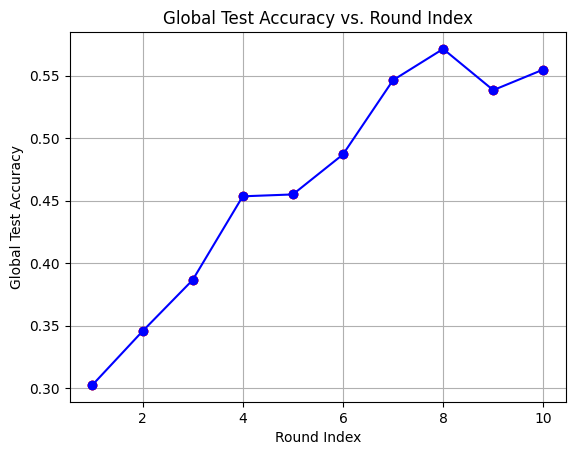

In [37]:
import matplotlib.pyplot as plt

# Example points (replace with your own x and y values)
x = accuracy_plot_x
y = accuracy_plot_y

# Scatter plot of points
plt.scatter(x, y, color='red', zorder=2)

# Plot line with markers
plt.plot(x, y, marker='o', linestyle='-', color='blue')

# Highlight the points explicitly if you like
plt.scatter(x, y, color='red')

plt.xlabel("Round Index")
plt.ylabel("Global Test Accuracy")
plt.title("Global Test Accuracy vs. Round Index")
plt.grid(True)
plt.show()


In [38]:
callback.save_to_csv(
    output_dir="results/nsga2",
    prefix="nsga2_run"
)


Pareto logging results saved:
  pareto: results/nsga2\nsga2_run_pareto.csv
  pareto_clients: results/nsga2\nsga2_run_pareto_clients.csv
  selected_solutions: results/nsga2\nsga2_run_selected_solutions.csv
  generations: results/nsga2\nsga2_run_generations.csv
  round_metrics: results/nsga2\nsga2_run_round_metrics.csv
  variances: results/nsga2\nsga2_run_variances.csv


{'pareto': 'results/nsga2\\nsga2_run_pareto.csv',
 'pareto_clients': 'results/nsga2\\nsga2_run_pareto_clients.csv',
 'selected_solutions': 'results/nsga2\\nsga2_run_selected_solutions.csv',
 'generations': 'results/nsga2\\nsga2_run_generations.csv',
 'round_metrics': 'results/nsga2\\nsga2_run_round_metrics.csv',
 'variances': 'results/nsga2\\nsga2_run_variances.csv'}